In [1]:
# Imports
import os
from pathlib import Path
markers = (".git", "Program")
current_dir = Path.cwd()
project_root = next((path for path in (current_dir, *current_dir.parents) if any((path / marker).exists() for marker in markers)), current_dir)
os.chdir(project_root)

import concurrent.futures
import cvxpy as cp
import datetime as dt
from functools import partial
from fundamentals import *
from helper_functions import modify_current_date, get_df, get_excel_filename, get_infix, get_volume5m_data, generate_end_dates, merge_stocks, stock_market
import itertools
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import multiprocessing
import numpy as np
import pandas as pd
from pandas import ExcelWriter as EW
import pickle
from plot import *
import random
from scipy.optimize import minimize
from scipy.stats import false_discovery_control, kendalltau, linregress, pearsonr, spearmanr, ttest_ind, wilcoxon
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from stock_screener import check_conds_tech, check_conds_fund, EM_rating, get_stock_info, stoploss_target
from technicals import *
from tqdm import tqdm

# Connect to TradingView
from tvDatafeed import TvDatafeed, Interval
tv = TvDatafeed()

# Start of the program
start = dt.datetime.now()

# Index
index_name = "^GSPC"
index_dict = {"^HSI": "HKEX", "^GSPC": "S&P 500", "^IXIC": "NASDAQ Composite"}

# Modify the current date
current_date = modify_current_date(start, index_name)

you are using nologin method, data you access may be limited


In [2]:
# --- Select Stock Universe from Excel File ---
# Load pre-screened stocks from the stock screener output file
def extract_metadata(rebalance_date, index_name, index_dict, period=252, RS=90, all_stocks=True, cap_threshold=10):
    """
    Extracts the stock universe and filters for Market Cap and all Trend/Growth conditions.
    """
    excel_filename = get_excel_filename(rebalance_date, index_name, index_dict, period, RS, all_stocks)
    excel_df = pd.read_excel(excel_filename)

    # Dynamically identify the Market Cap column (e.g., USD, HKD, CNY)
    market_cap_matches = [col for col in excel_df.columns if re.match(r"Market Cap \(B, .*", col)]
    
    if not market_cap_matches:
        print(f"Warning: No Market Cap column found for {rebalance_date}. Skipping cap filter.")
        # If no cap column, we just create a mask of all True to avoid crashing
        market_cap_mask = pd.Series([True] * len(excel_df))
        market_cap_col = None
    else:
        market_cap_col = market_cap_matches[0]
        market_cap_mask = excel_df[market_cap_col] > cap_threshold
    
    # Check if all condition columns exist in the current Excel file
    cond_cols = ["cond_t1", "cond_t3", "cond_t4", "cond_t5", "cond_f2", "cond_f3"]
    has_all_conds = set(cond_cols).issubset(excel_df.columns)
    
    # Construct the filtering mask
    mask = market_cap_mask
    if has_all_conds:
        # Modern file logic: Add the requirement that ALL conditions must be True
        mask = mask & excel_df[cond_cols].all(axis=1)
        print(f"Applied full filters for {rebalance_date}. Found {mask.sum()} stocks.")
    else:
        # Legacy file logic: Fallback to only Market Cap
        pass 
        print(f"Columns missing for {rebalance_date}. Falling back to Market Cap only.")
    
    # Extract metadata (avoid SettingWithCopy); include Market Cap if present
    info_cols = ["Stock"] + ([market_cap_col] if market_cap_col else [])
    metadata_df = excel_df.loc[mask, info_cols].copy()

    # Standardize the Market Cap column name
    if market_cap_col:
        metadata_df.rename(columns={market_cap_col: "Market Cap"}, inplace=True)
    
    return metadata_df.reset_index(drop=True)

# --- Fetch Price Data ---
# Fetch historical closing prices for all stocks
def fetch_price_data(stocks, rebalance_date, min_required_days=252, benchmark="^GSPC"):
    # Include S&P 500 in the calculation
    all_tickers = stocks + [benchmark]
    price_data = {}
    valid_stocks = []

    for stock in tqdm(all_tickers, desc="Fetching price data"):
        try:
            df = get_df(stock, rebalance_date)
            if df is None or df.empty:
                continue
            
            # Ensure data is up to rebalance_date
            # Use <= for weekends (Saturday/Sunday) to include Friday's data
            # Use < for weekdays to exclude the rebalance date itself
            rebalance_dt = pd.to_datetime(rebalance_date)
            if rebalance_dt.weekday() >= 5:
                df = df[df.index <= rebalance_date]
            else:
                df = df[df.index < rebalance_date]
            
            # Key check: data length must be sufficient to support your backtest window (252 days)
            if len(df) < min_required_days:
                print(f"Warning: {stock} has insufficient data ({len(df)} days). Skipping...")
                continue
                
            price_data[stock] = df["Close"]
            if stock != benchmark:
                valid_stocks.append(stock)
        except Exception as e:
            print(f"Error fetching {stock}: {e}")
            continue

    return price_data, valid_stocks

# --- Weekly Returns Z-Score Analysis ---
# Z-score measures how unusual this week's return is vs historical weekly returns
def compute_weekly_return_zscores(price_data, valid_stocks, period_week_zscore, days_per_week):
    # Take the last period_week_zscore + days_per_week rows for each stock
    df_prices = pd.DataFrame({stock: price_data[stock].tail(period_week_zscore + days_per_week + 1) for stock in valid_stocks})
    
    # Reverse the rows so we start sampling from the most recent day
    df_prices_rev = df_prices.iloc[::-1]
    
    # Sample every "days_per_week" starting from the last day
    weekly_prices_rev = df_prices_rev.iloc[::days_per_week]
    
    # Reverse back to chronological order
    weekly_prices = weekly_prices_rev.iloc[::-1]
    
    # Compute weekly returns
    weekly_returns = weekly_prices.pct_change(fill_method=None).dropna()

    # SEPARATE: Historical vs. Recent
    hist_returns = weekly_returns.iloc[:-1]
    recent_return = weekly_returns.iloc[-1]

    # Compute statistics based ONLY on history
    mean_hist = hist_returns.mean()
    std_hist = hist_returns.std()
    
    # Compute statistics
    mean_return = weekly_returns.mean()
    std_return = weekly_returns.std()
    recent_return = weekly_returns.iloc[-1]
    z_scores = (recent_return - mean_hist) / std_hist

    return weekly_returns, mean_return, std_return, recent_return, z_scores

# --- Momentum and Volatility Analysis ---
# Momentum: price ratio (recent / year-ago) - measures trend strength over 1 year
# Volatility: standard deviation of daily returns - measures price variability
# Vol-adj Momentum: momentum / volatility - risk-adjusted trend
def calculate_momentum_volatility(price_data, valid_stocks, period_mom_short, period_mom_long, period_vol, benchmark="^GSPC"):
    """
    Calculates Total Momentum, Idiosyncratic Momentum, and Volatility.
    
    Parameters:
    - price_data: DataFrame with columns as tickers and rows as dates ("Close").
    - valid_stocks: List of stock tickers to analyze.
    - period_mom_short: The "recent" exclusion period (e.g., 21 for 1 month).
    - period_mom_long: The lookback period (e.g., 252 for 1 year).
    - period_vol: Lookback for volatility (e.g., 60).
    - benchmark: Ticker for the market index (e.g., ^GSPC).
    
    Returns:
    - momentum_list, idio_momentum_list, volatility_list
    """
    # Include S&P 500 in the calculation
    all_tickers = valid_stocks + [benchmark]

    # Ensure benchmark data is available
    if benchmark not in price_data:
        raise ValueError("Benchmark data missing. Cannot compute idiosyncratic momentum.")
    
    # Build DataFrame once for vectorized operations
    df_prices = pd.DataFrame({stock: price_data[stock].tail(period_mom_long + 1) for stock in all_tickers})

    # Vectorized calculation of daily returns
    daily_returns = df_prices.pct_change(fill_method=None).dropna()

    # Vectorized volatility calculation: std of daily returns over period_vol
    volatility_series = daily_returns[valid_stocks].tail(period_vol).std()
    
    # Vectorized calculation of total momentum
    momentum_series = df_prices[valid_stocks].iloc[- period_mom_short] / df_prices[valid_stocks].iloc[- period_mom_long] - 1
    
    # Vectorized beta calculation
    # We calculate the covariance matrix of ALL stocks + Benchmark
    # Then we select only the column corresponding to the benchmark
    cov_matrix = daily_returns.cov()
    cov_with_benchmark = cov_matrix[benchmark].loc[valid_stocks] # Filter for just our stocks
    beta_series = cov_with_benchmark / daily_returns[benchmark].var()
    
    # Calculate idiosyncratic momentum
    # Formula: r_idio = r_stock - (beta * r_market)
    
    # Calculate benchmark return over the same specific window
    benchmark_return = df_prices[benchmark].iloc[- period_mom_short] / df_prices[benchmark].iloc[- period_mom_long] - 1
    
    # Calculate residuals
    idio_momentum_series = momentum_series - (beta_series * benchmark_return)

    # Convert series to lists
    return momentum_series.tolist(), idio_momentum_series.tolist(), volatility_series.tolist()

# --- Hierarchical Clustering Analysis ---
# Groups stocks by return correlation using Ward's linkage (minimizes within-cluster variance)
def hierarchical_clustering(price_data, valid_stocks, period_pca, num_clusters, hca_linkage="ward"):
    # Ensure we have at least 2 stocks to cluster
    if len(valid_stocks) < 2:
        return None, np.array([1] * len(valid_stocks))

    # Build the price dataframe
    prices_df = pd.DataFrame({stock: price_data[stock].tail(period_pca) for stock in valid_stocks})
    
    # Calculate returns
    returns = prices_df.pct_change(fill_method=None)
    
    # Check if we have enough valid rows to calculate correlation
    # We need at least 2 rows of returns to have a correlation
    if len(returns.dropna(how="all")) < 2:
        print(f"Warning: Not enough data for clustering in this period. Skipping...")
        return None, np.array([1] * len(valid_stocks))

    # Correlation Matrix
    corr_matrix = returns.corr()
    
    # Handle NaNs in the correlation matrix (caused by zero volatility/flat prices)
    corr_matrix = corr_matrix.fillna(0)
    
    # Convert to distance matrix
    dist_matrix = np.sqrt(2 * (1 - corr_matrix))
    
    # Hierarchical clustering
    try:
        # squareform() expects a symmetric matrix with 0s on the diagonal
        condensed_dist = squareform(dist_matrix, checks=False)
        
        if condensed_dist.size == 0:
            raise ValueError("Condensed distance matrix is empty.")
            
        Z = linkage(condensed_dist, method=hca_linkage)
        cluster_labels = fcluster(Z, t=num_clusters, criterion="maxclust")
        return Z, cluster_labels
        
    except Exception as e:
        print(f"Clustering failed: {e}")
        # Fallback: Assign everyone to Cluster 1
        return None, np.array([1] * len(valid_stocks))

# --- Combine All Metrics into Single DataFrame ---
def create_combined_dataframe(valid_stocks, metadata_df, cluster_labels, momentum_list, idio_momentum_list, volatility_list, 
                               mean_return, std_return, recent_return, z_scores):
    """
    Consolidate all computed metrics into a single DataFrame for analysis.
    Adds vol-adjusted momentum and ranks stocks by this metric.
    """
    df_combined = pd.DataFrame({
        "Stock": valid_stocks,
        "Cluster": cluster_labels,
        "Momentum": momentum_list,
        "Idio Momentum": idio_momentum_list,
        "Volatility": volatility_list,
        "Mean Weekly Return (%)": (mean_return * 100).values,
        "Std Weekly Return (%)": (std_return * 100).values,
        "This Week Return (%)": (recent_return * 100).values,
        "Z-Score": z_scores.values
    })

    # --- Merge with stock metadata (e.g., Market Cap)
    # We use a "left" join to keep only the valid stocks that passed the price-fetch stage
    df_combined = df_combined.merge(metadata_df, on="Stock", how="left")
    
    # Vol-adjusted momentum: normalize momentum by volatility for risk-adjusted comparison
    df_combined["Vol-adj Momentum"] = df_combined["Momentum"] / df_combined["Volatility"]
    df_combined["Vol-adj Idio Momentum"] = df_combined["Idio Momentum"] / df_combined["Volatility"]
    
    # Sort by vol-adjusted momentum (descending) and create rank index starting from 1
    df_combined = df_combined.sort_values("Vol-adj Momentum", ascending=False).reset_index(drop=True)
    df_combined.index = df_combined.index + 1
    df_combined.index.name = "Rank"
    return df_combined

# --- Dendrogram Visualization ---
def plot_dendrogram(Z, valid_stocks, period_pca):
    """
    Visualize hierarchical clustering structure as a dendrogram.
    Y-axis (distance) shows how dissimilar clusters are when merged.
    """
    plt.figure(figsize=(14, 8))
    dendrogram(Z, labels=valid_stocks, leaf_rotation=90, leaf_font_size=8)
    plt.title(f"Hierarchical Clustering of {len(valid_stocks)} Stocks (Past {period_pca} Days)")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

# --- Filter and Display Stocks by Cluster ---
# Exclude stocks with z-score > 2 (unusually high recent returns)
# These may be experiencing unsustainable spikes rather than steady momentum
def filter_stocks_by_zscore(df_combined, z_score_threshold=2):
    """Filter stocks and display by cluster."""
    df_filtered = df_combined[np.abs(df_combined["Z-Score"]) <= z_score_threshold]

    print(f"Stocks by Cluster (Ranked by Vol-adj Momentum, |Z-Score| <= {z_score_threshold}):")
    for cluster_id in sorted(df_filtered["Cluster"].unique()):
        cluster_df = df_filtered[df_filtered["Cluster"] == cluster_id]
        cluster_stocks = cluster_df["Stock"].tolist()
        print(f"Cluster {cluster_id} ({len(cluster_df)} stocks): {', '.join(cluster_stocks)}")
    
    return df_filtered

def select_top_stocks_with_weights(df_combined, num_stocks, use_hca=True, cluster_cap=0.4):
    """
    Select top stocks using HCA cluster-aware selection or simple momentum.
    """
    if df_combined.empty or df_combined is None:
        return pd.DataFrame()
    
    # Ensure the dataframe is sorted by vol-adjusted momentum before ranking
    df_copy = df_combined.sort_values("Vol-adj Momentum", ascending=False).copy()

    # Assign intra-cluster rank
    df_copy["Intra-cluster Rank"] = df_copy.groupby("Cluster").cumcount()

    if use_hca:
        # Sort: First by intra-cluster rank, then by the original sort order (Vol-adj Momentum)
        top_stocks = df_copy.sort_values(by=["Intra-cluster Rank", "Vol-adj Momentum"], ascending=[True, False]).head(num_stocks)

    else:
        # Calculate the dynamic limit per cluster
        max_per_cluster = math.ceil(num_stocks * (cluster_cap if cluster_cap else 1.0))
        # Simple momentum selection
        top_stocks = df_copy[df_copy["Intra-cluster Rank"] < max_per_cluster].head(num_stocks)

    # Define target weights (inverse volatility)
    volatilities = top_stocks["Volatility"].values
    inv_vol = 1 / volatilities
    target_weights = inv_vol / inv_vol.sum()

    if cluster_cap is None:
        # Use target weights directly (no cluster cap)
        weights = target_weights
    else:
        # --- Convex Optimization using CVXPY ---
        clusters = top_stocks["Cluster"].values
        unique_clusters = np.unique(clusters)
    
        # Variable: The weights we want to find
        num_stocks = len(top_stocks)
        w = cp.Variable(num_stocks)

        # Objective: Minimize squared distance from target weights (tracking error)
        # This is a quadratic objective
        objective = cp.Minimize(cp.sum_squares(w - target_weights))

        # Constraints
        constraints = [
            cp.sum(w) == 1.0, # Fully invested
            w >= 0 # Long only (no shorting)
        ]

        # Check if cluster cap is mathematically possible
        is_feasible = cluster_cap is not None and (len(unique_clusters) * cluster_cap >= 1.0)

        # Cluster constraints
        if is_feasible:
            # Find the integer indices of stocks belonging to this cluster
            for cluster in unique_clusters:
                indices = [i for i, c_val in enumerate(clusters) if c_val == cluster]
                constraints.append(cp.sum(w[indices]) <= cluster_cap)
        else:
            if num_stocks > 0:
                print(f"Warning: cluster_cap {cluster_cap} is impossible with {len(unique_clusters)} clusters. Relaxing cap.")

        # OSQP solver
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.OSQP)

        # Get results
        if w.value is None:
            # Fallback (Theoretical only; convex problems shouldn't fail unless constraints are impossible)
            print("Optimization failed. Using target weights.")
            weights = target_weights
        else:
            weights = w.value
            # Re-normalize just to be safe after rounding
            weights = weights / np.sum(weights)
        
    return pd.DataFrame({
        "Cluster": top_stocks["Cluster"],
        "Stock": top_stocks["Stock"],
        "Market Cap": top_stocks["Market Cap"],
        "Volatility": volatilities,
        "Vol-adj Momentum": top_stocks["Vol-adj Momentum"],
        "Vol-adj Idio Momentum": top_stocks["Vol-adj Idio Momentum"],
        "Z-Score": top_stocks["Z-Score"],
        "Weight (%)": weights * 100,
    }).sort_values("Stock").reset_index(drop=True)

In [3]:
# --- Main Monthly Portfolio Construction Function ---
def construct_month_portfolio(rebalance_date, index_name, index_dict, parameters, use_hca=True, hca_linkage="ward", display_dendrogram=False, cluster_cap=0.4, exclude_stocks=None):
    """
    Construct a monthly momentum portfolio based on hierarchical clustering and vol-adjusted momentum.
    """

    # Normalize exclude_stocks to a set for O(1) lookups
    if isinstance(exclude_stocks, str):
        exclude_stocks = [exclude_stocks]
    exclude_set = set(exclude_stocks or [])

    # Extract stock universe and metadata from the screener output
    metadata_df = extract_metadata(rebalance_date, index_name, index_dict)
    stocks = metadata_df["Stock"].tolist()

    # Remove any explicitly excluded stocks before processing
    if exclude_stocks:
        stocks = [stock for stock in stocks if stock not in exclude_set]

    # Check if we have enough stocks
    if len(stocks) < 1:
        print("Not enough stocks to construct a portfolio.")
        return pd.DataFrame(), 0, pd.DataFrame()
    
    # Fetch price data
    price_data, valid_stocks = fetch_price_data(stocks, rebalance_date)
    
    # Weekly returns z-score analysis
    weekly_returns, mean_return, std_return, recent_return, z_scores = compute_weekly_return_zscores(
        price_data, valid_stocks, parameters["period_week_zscore"], parameters["days_per_week"])
    
    # Momentum and volatility calculation
    momentum_list, idio_momentum_list, volatility_list = calculate_momentum_volatility(
        price_data, valid_stocks, parameters["period_mom_short"], parameters["period_mom_long"], parameters["period_vol"])
    
    # Hierarchical clustering
    Z, cluster_labels = hierarchical_clustering(price_data, valid_stocks, parameters["period_pca"], parameters["num_clusters"], hca_linkage=hca_linkage)

    # Plot dendrogram
    if display_dendrogram and Z is not None:
        plot_dendrogram(Z, valid_stocks, parameters["period_pca"])
    
    # Create combined DataFrame
    df_combined = create_combined_dataframe(
        valid_stocks, metadata_df, cluster_labels, momentum_list, idio_momentum_list, volatility_list,
        mean_return, std_return, recent_return, z_scores)
    
    # Filter stocks by z-score
    df_filtered = filter_stocks_by_zscore(df_combined)

    # Extract number of stocks after filtering
    num_stocks_filtered = len(df_filtered)
    print(f"Number of stocks after Z-Score filtering: {num_stocks_filtered}\n")
    
    # Select top stocks with weights
    portfolio_df = select_top_stocks_with_weights(df_filtered, num_stocks=parameters["num_stocks"], use_hca=use_hca, cluster_cap=cluster_cap)
    
    return portfolio_df, num_stocks_filtered, df_combined

def get_cache_filename(strat):
    """Use a stable name for the cache file to allow updates."""
    # Define the result folder
    result_folder = "Result"

    # Define the filename
    filename = os.path.join(result_folder, f"portfolio_cache_{strat}.pkl")
    
    return filename

def load_cache(strat):
    filename = get_cache_filename(strat)
    if os.path.exists(filename):
        with open(filename, "rb") as f:
            return pickle.load(f)
    return {}

def save_cache(strat, data):
    filename = get_cache_filename(strat)
    with open(filename, "wb") as f:
        pickle.dump(data, f)

In [4]:
def align_series(target, predictor):
    """
    Aligns two series to the same time range.
    """
    # Find the overlapping date range
    common_start = max(target.index.min(), predictor.index.min())
    common_end = min(target.index.max(), predictor.index.max())
    
    # Slice both to the common range
    target = target.loc[common_start:common_end]
    predictor = predictor.loc[common_start:common_end]
    
    return target, predictor

def analyze_predictive_power(target_series, predictor_series, max_lags=20):
    """
    Checks if predictor_series Granger-causes target_series.
    """
    # Align series
    target, predictor = align_series(target_series, predictor_series)
    
    # Combine into one DataFrame
    df = pd.concat([target, predictor], axis=1).dropna()
    df.columns = ["Target", "Predictor"]
    
    print(f"Analysis period: {df.index.min()} to {df.index.max()}")
    print(f"Number of observations: {len(df)}")

    # Check for Stationarity (ADF Test)
    for col in df.columns:
        dftest = adfuller(df[col], autolag="AIC")
        p_val = dftest[1]
        status = "Stationary" if p_val < 0.05 else "NOT Stationary"
        print(f"[{col}] p-value: {p_val:.4f} ({status})")

    # Granger Causality Test
    print(f"\n--- Granger Causality Test (Does Predictor help forecast Target?) ---")
    results = grangercausalitytests(df[["Target", "Predictor"]], maxlag=max_lags, verbose=True)
    
    return results

In [5]:
# --- Parameters ---
days_per_week = 5  # Trading days in a week
num_weeks = 52  # Weeks in a year
period_week_zscore = days_per_week * num_weeks  # 1-year lookback for weekly return z-score
period_pca = 126  # 6-month lookback for PCA clustering
period_mom_short = 21  # 1-month lookback for short-term momentum
period_mom_long = 252  # 1-year lookback for long-term momentum
period_vol = 60  # 3-month volatility window
num_clusters = 5  # Number of clusters for hierarchical grouping
num_stocks = 5  # Number of stocks to select for the portfolio
parameters = {
    "days_per_week": days_per_week,
    "period_week_zscore": period_week_zscore,
    "period_pca": period_pca,
    "period_mom_short": period_mom_short,
    "period_mom_long": period_mom_long,
    "period_vol": period_vol,
    "num_clusters": num_clusters,
    "num_stocks": num_stocks
}

In [6]:
# --- Rebalance dates for monthly portfolio analysis ---
rebalance_dates = [
    "2024-02-01", "2024-03-01", "2024-04-01", "2024-05-01", "2024-05-31",
    "2024-07-01", "2024-08-03", "2024-08-31", "2024-10-03", "2024-11-02", 
    "2024-11-30", "2025-01-04", "2025-02-01", "2025-03-01", "2025-04-05", 
    "2025-05-01", "2025-06-03", "2025-07-01", "2025-08-01", "2025-09-06", 
    "2025-10-01", "2025-11-01", "2025-12-04", "2026-01-03", "2026-01-17", 
    "2026-01-31", "2026-02-28"
]

In [7]:
# --- Main Construction Logic ---
configs = [
    {"strat": "hca", "use_hca": True, "cluster_cap": 0.4},
    {"strat": "nohca_cap40", "use_hca": False, "cluster_cap": 0.4},
    {"strat": "nohca_nocap", "use_hca": False, "cluster_cap": None}
]

# Load existing data into a master dictionary
portfolio_dicts = {config["strat"]: load_cache(config["strat"]) for config in configs}

# --- Force re-run for specific datese ---
force_rerun_dates = ["2026-03-07"]
for date, config in itertools.product(force_rerun_dates, configs):
    portfolio_dicts[config["strat"]].pop(date, None)

# Identify which dates are missing across ALL configs
all_cached_dates = set(portfolio_dicts["hca"].keys())
dates_ext = [date for date in rebalance_dates if date not in all_cached_dates]

if not dates_ext:
    print("All dates already cached. Skipping construction.")
else:
    print(f"Found {len(dates_ext)} new dates to process.")
    
    # Only loop through the NEW dates
    for date in tqdm(dates_ext, desc="Updating Portfolios"):
        for config in configs:
            # Add exclude_stocks for the force rerun date
            exclude_stocks = "EXAS" if date == "2026-03-07" else None

            # Construct the portfolio
            portfolio_df, _, _ = construct_month_portfolio(
                date, index_name, index_dict, parameters, 
                use_hca=config["use_hca"], 
                cluster_cap=config["cluster_cap"],
                exclude_stocks=exclude_stocks
            )
            
            # Add new date to the existing dictionary
            portfolio_dicts[config["strat"]][date] = portfolio_df

    # Save the updated dictionaries
    for config in configs:
        save_cache(config["strat"], portfolio_dicts[config["strat"]])

# Extract for use in backtest
monthly_portfolios_hca = portfolio_dicts["hca"]
monthly_portfolios_nohca_cap40 = portfolio_dicts["nohca_cap40"]
monthly_portfolios_nohca_nocap = portfolio_dicts["nohca_nocap"]

# Verification: Print the last date processed
last_rebalance_date = max(monthly_portfolios_hca.keys())
print(f"Cache updated. Latest date available: {last_rebalance_date}")

All dates already cached. Skipping construction.
Cache updated. Latest date available: 2026-03-04


In [29]:
# Pre-calculate daily returns for portfolios
def get_period_returns(portfolio, period_dates, buy_date, sell_date, sp500_df, daily_rf_ret, 
                       stop_loss=True, stop_zscore=-2.0, stop_position=0.5, slippage_fee_rate=0.002):    

    def calculate_custom_returns(prices_series, opens_series, stop_trigger_date, stop_series=None):
        """Calculate custom daily returns with stop-loss and rebalance exit logic."""
        # Initialize all returns to the daily risk-free rate (cash)
        rets = pd.Series(daily_rf_ret, index=period_dates)

        # Determine exit date
        exit_date = stop_trigger_date if stop_trigger_date else sell_date
        active_dates = [date for date in period_dates if date <= exit_date]

        if not active_dates: 
            return rets

        # Standard daily returns (Close / Prev Close)
        active_prices = prices_series.reindex(active_dates).ffill()
        active_opens = opens_series.reindex(active_dates).ffill()
        active_rets = active_prices / active_prices.shift(1)

        # Buy date logic: buy at Open (Close / Open)
        if buy_date in active_dates:
            buy_open = active_opens.loc[buy_date]
            if buy_open > 0:
                active_rets.loc[buy_date] = active_prices.loc[buy_date] / buy_open

        # Intraday stop-loss execution (half position sold)
        if stop_trigger_date and stop_trigger_date in active_rets.index and stop_series is not None:
            stop_price = stop_series.loc[stop_trigger_date]
            day_open = active_opens.loc[stop_trigger_date]
            
            # If the stock gapped down below our stop, fill at Open; otherwise fill at stop
            fill_price = min(day_open, stop_price)
            exit_price = fill_price * (1.0 - slippage_fee_rate)

            # Calculate returns for the sold half and held half on the stop day
            sold_part_ret, hold_part_ret = 1.0, 1.0

            if stop_trigger_date == buy_date:
                # Edge case: stopped out on the same day we bought
                buy_open = active_opens.loc[buy_date]
                if buy_open > 0:
                    sold_part_ret = exit_price / buy_open
                    hold_part_ret = active_prices.loc[stop_trigger_date] / buy_open
            else:
                # Normal case: stopped out on a subsequent day (exit / prev close)
                prev_close = prices_series.shift(1).loc[stop_trigger_date]
                if prev_close > 0:
                    sold_part_ret = exit_price / prev_close
                    hold_part_ret = active_prices.loc[stop_trigger_date] / prev_close
            
            # Calculate total return for the stop day
            total_stop_day_ret = stop_position * sold_part_ret + (1 - stop_position) * hold_part_ret
            active_rets.loc[stop_trigger_date] = total_stop_day_ret

            # Dynamic weight tracking for remaining days
            if total_stop_day_ret > 0:
                cash_weight = (stop_position * sold_part_ret) / total_stop_day_ret
                stock_weight = ((1 - stop_position) * hold_part_ret) / total_stop_day_ret
            else:
                cash_weight, stock_weight = stop_position, 1 - stop_position

            remain_dates = [date for date in period_dates if stop_trigger_date < date <= sell_date]
            if remain_dates:
                remain_prices = prices_series.reindex(remain_dates).ffill()
                remain_opens = opens_series.reindex(remain_dates).ffill()
                
                for i, date in enumerate(remain_dates):
                    # Daily multiplier for the held half
                    prev_close = active_prices.loc[stop_trigger_date] if i == 0 else remain_prices.loc[remain_dates[i - 1]]
                    held_half_daily_ret = remain_prices.loc[date] / prev_close if prev_close > 0 else 1.0
                    
                    # Sell date override: exit at Open
                    if date == sell_date:
                        sell_open = remain_opens.loc[sell_date]
                        if prev_close > 0:
                            held_half_daily_ret = sell_open / prev_close
                    
                    # Calculate total return using dynamic weights, then update weights for next day
                    total_ret = (cash_weight * daily_rf_ret) + (stock_weight * held_half_daily_ret)
                    rets.loc[date] = total_ret
                    
                    if total_ret > 0:
                        cash_weight = (cash_weight * daily_rf_ret) / total_ret
                        stock_weight = (stock_weight * held_half_daily_ret) / total_ret

        # Monthly rebalance exit (Open / Prev Close) — only if no stop triggered
        elif stop_trigger_date is None:
            if sell_date in active_opens.index and len(active_dates) >= 2:
                sell_open = active_opens.loc[sell_date]
                prev_close = active_prices.iloc[-2]
                if prev_close > 0:
                    active_rets.loc[sell_date] = sell_open / prev_close

        rets.update(active_rets)
        return rets.fillna(daily_rf_ret)

    # Fallback: no portfolio — use S&P 500
    if portfolio is None or portfolio.empty:
        prices = sp500_df["Close"].reindex(period_dates).ffill()
        opens = sp500_df["Open"].reindex(period_dates).ffill()
        return calculate_custom_returns(prices, opens, None, None)

    # Portfolio logic
    rets_list = []
    
    for _, row in portfolio.iterrows():
        ticker = row["Stock"]
        weight = row["Weight (%)"] / 100
        
        stock_df = get_df(ticker, sell_date.strftime("%Y-%m-%d"))

        if stock_df is not None and not stock_df.empty and buy_date in stock_df.index:
            # Indicator calculations (shifted by 1 so today's stop uses yesterday's data)
            ret_5d = stock_df["Close"].pct_change(5).shift(1)
            mean_52 = ret_5d.rolling(window=260).mean()
            std_52 = ret_5d.rolling(window=260).std()
            z_price = stock_df["Close"].shift(5 + 1) * (1 + mean_52 + (stop_zscore * std_52))

            # Anchored 5-day mask: active only at buy_idx, buy_idx+5, buy_idx+10, etc.
            buy_idx = stock_df.index.get_loc(buy_date)
            all_indices = np.arange(len(stock_df))
            mask = (all_indices >= buy_idx) & ((all_indices - buy_idx) % 5 == 0)
            
            # Apply mask and forward-fill to freeze the level for 5 days
            stop_level = z_price.where(mask).ffill()

            # Align prices and stop levels to the period
            prices = stock_df["Close"].reindex(period_dates).ffill()
            opens = stock_df["Open"].reindex(period_dates).ffill()
            lows = stock_df["Low"].reindex(period_dates).ffill()                
            stops = stop_level.reindex(period_dates).ffill()
            
            # Check for intraday stop trigger (exclude sell date — we sell at Open anyway)
            stop_trigger_date = None
            if stop_loss:
                check_dates = [date for date in period_dates if date < sell_date]
                
                for date in check_dates:
                    if pd.notna(stops.loc[date]) and lows.loc[date] <= stops.loc[date]:
                        stop_trigger_date = date
                        break

            if stop_trigger_date:
                level = stops.loc[stop_trigger_date]
                day_open = opens.loc[stop_trigger_date]
                fill_price = min(day_open, level)

                print(f"Date: {stop_trigger_date.strftime('%Y-%m-%d')}, Stock: {ticker}, "
                    f"Stop Level: ${level:.2f}, Fill Price: ${fill_price:.2f} " + ("(GAP DOWN)" if day_open < level else "") + "\n")

            # Pass stops so the inner function knows the exact fill price
            stock_rets = calculate_custom_returns(prices, opens, stop_trigger_date, stops)
            rets_list.append(stock_rets * weight)
            
        else:
            rets_list.append(pd.Series(weight, index=period_dates))

    return pd.concat(rets_list, axis=1).sum(axis=1)


In [30]:
# Get backtest and trading dates
def get_backtest_trading_dates(sp500_df, rebalance_dates):
    trading_dates = sp500_df.index
    backtest_dates = rebalance_dates.copy()
    last_trading_date = trading_dates[-1].strftime("%Y-%m-%d")
    backtest_dates = [date for date in backtest_dates if date <= last_trading_date]
    if backtest_dates[-1] < last_trading_date:
        backtest_dates.append(last_trading_date) # Append the last trading date if not already included
    return backtest_dates, trading_dates

# Calculate drawdowns
def get_drawdown(series):
    rolling_max = series.cummax()
    return (series - rolling_max) / rolling_max

# --- Performance Metrics Calculation ---
def calculate_metrics(series, annual_rf_rate=0.03):
    # Calculate daily returns for volatility and risk-adjusted ratios
    returns = series.pct_change().dropna()
    
    # Annualized Return (CAGR)
    total_return = (series.iloc[-1] / series.iloc[0]) - 1
    years = (series.index[-1] - series.index[0]).days / 365.25
    cagr = (1 + total_return) ** (1 / years) - 1
    
    # Annualized Volatility
    vol = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio
    sharpe = (cagr - annual_rf_rate) / vol

    # Sortino Ratio (downside deviation only)
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside_vol
    
    # Maximum Drawdown
    rolling_max = series.cummax()
    drawdowns = (series - rolling_max) / rolling_max
    max_dd = drawdowns.min()
    
    # Calmar Ratio
    calmar = cagr / abs(max_dd)
    
    return {
        "CAGR": f"{cagr:.2%}",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Calmar": f"{calmar:.2f}",
        "Annualized Vol": f"{vol:.2%}",
        "Max DD": f"{max_dd:.2%}"
    }

# EWMA volatility targeting
def calculate_vol_scale(portfolio_df, rebalance_date, target_vol=0.20, LAMBDA=0.94):
    prices = {}
    weights = {}
    
    # Gather all closing prices into a dictionary
    for _, row in portfolio_df.iterrows():
        ticker = row["Stock"]
        weight = row["Weight (%)"] / 100
        
        stock_df = get_df(ticker, rebalance_date)
        stock_df = stock_df[stock_df.index <= rebalance_date]
        
        prices[ticker] = stock_df["Close"]
        weights[ticker] = weight
        
    # Combine into a single DataFrame
    # This perfectly aligns all dates on the index
    prices_df = pd.DataFrame(prices)
    
    # Handle missing data
    # Forward-fill prices (e.g., if a stock was halted or missing a day, 
    # its price stays the same, resulting in a 0% return rather than a NaN break)
    prices_df = prices_df.ffill().dropna(how="all")
    
    # Calculate daily returns for all stocks simultaneously
    rets_df = prices_df.pct_change().dropna(how="all")
    
    # If a stock IPO'd recently and has NaNs at the start of the window, fill with 0
    rets_df = rets_df.fillna(0)
    
    # Calculate Pro-Forma Portfolio Daily Returns
    # Multiply the returns matrix by the weights series and sum across the columns (axis=1)
    port_rets = (rets_df * pd.Series(weights)).sum(axis=1)
    
    # Apply EWMA Math
    if len(port_rets) >= 21:
        # Standard daily vol EWMA
        ewma_var = port_rets.pow(2).ewm(alpha=(1 - LAMBDA), adjust=False).mean().iloc[-1]
        ewma_annual_vol = np.sqrt(ewma_var) * np.sqrt(252) # Annualize
        
        # Prevent division by zero just in case
        if ewma_annual_vol > 0:
            vol_scale = target_vol / ewma_annual_vol
        else:
            vol_scale = 1.0
    else:
        vol_scale = 1.0
        
    return vol_scale

# Simple 20-day rolling volatility targeting
def calculate_vol_scale_simple(portfolio_df, rebalance_date, target_vol=0.20, window=21):
    prices = {}
    weights = {}
    
    # Gather all closing prices into a dictionary
    for _, row in portfolio_df.iterrows():
        ticker = row["Stock"]
        weight = row["Weight (%)"] / 100
        
        stock_df = get_df(ticker, rebalance_date)
        stock_df = stock_df[stock_df.index <= rebalance_date]
        
        prices[ticker] = stock_df["Close"]
        weights[ticker] = weight
        
    # Combine into a single DataFrame
    prices_df = pd.DataFrame(prices)
    
    # Handle missing data
    prices_df = prices_df.ffill().dropna(how="all")
    
    # Calculate daily returns for all stocks simultaneously
    rets_df = prices_df.pct_change().dropna(how="all")
    
    # If a stock IPO'd recently and has NaNs at the start of the window, fill with 0
    rets_df = rets_df.fillna(0)
    
    # Calculate Pro-Forma Portfolio Daily Returns
    port_rets = (rets_df * pd.Series(weights)).sum(axis=1)
    
    # Apply 20-day rolling volatility
    if len(port_rets) >= window:
        # Use the last "window" days of returns
        recent_rets = port_rets.iloc[-window:]
        rolling_vol = recent_rets.std() * np.sqrt(252)  # Annualize
        
        # Prevent division by zero
        if rolling_vol > 0:
            vol_scale = target_vol / rolling_vol
        else:
            vol_scale = 1.0
    else:
        vol_scale = 1.0
        
    return vol_scale

def apply_fees(capitals, trade_size, fee_rate, strats=None):
    """Applies transaction fees to a dictionary of capital values."""
    fee_factor = 1 - (fee_rate * trade_size)
    keys = strats if strats else capitals.keys()
    for key in keys:
        capitals[key] *= fee_factor
    return capitals

def get_growth(strat, date, exposure, mmfi_exposure, daily_rets, daily_rf_ret, daily_margin_ret, tqqq_df, spmo_df, buy_tqqq, is_sell_date=False):
    """Calculates the growth factor for a specific strategy on a specific date."""
    if strat == "spmo":
        # Prevent double compounding the ETF daily return on overlapping transition days
        stock_ret = 1.0 if is_sell_date else spmo_df["Daily Return"].loc[date]
    else:
        stock_ret = daily_rets[strat].loc[date]
        
    tqqq_exposure = mmfi_exposure if buy_tqqq else 0.0
    # Prevent double compounding TQQQ daily return
    tqqq_ret = 1.0 if is_sell_date else tqqq_df["Daily Return"].loc[date]
    
    cash_exposure = 1 - exposure - tqqq_exposure
    cash_ret = daily_rf_ret if cash_exposure > 0 else daily_margin_ret
    # Prevent double compounding the risk-free rate / margin interest
    if is_sell_date:
        cash_ret = 1.0
        
    growth = stock_ret * exposure + tqqq_ret * tqqq_exposure + cash_ret * cash_exposure
    return growth

def calculate_exposure(mmth_df, signal_date, vol_scale, mmth_filter=True):
    """Calculates the exposure based on MMTH and volatility scaling."""
    if mmth_filter:
        # Base exposure from MMTH
        current_mmth = mmth_df["Close"].loc[signal_date]

        # Apply volatility scaling to the base exposure
        base_exposure = 0.0 if current_mmth < 50 else 1.0
        active_exposure = base_exposure * np.clip(vol_scale, 0.0, 1.0)
    else:
        base_exposure = 1.0
        active_exposure = base_exposure * np.clip(vol_scale, 0.0, 1.0)
    active_exposure_spmo = base_exposure
    return active_exposure, active_exposure_spmo

Date: 2024-02-13, Stock: JHX, Stop Level: $34.67, Fill Price: $34.67 

Date: 2024-03-19, Stock: SMCI, Stop Level: $89.76, Fill Price: $88.86 (GAP DOWN)

Date: 2024-03-19, Stock: SMCI, Stop Level: $89.76, Fill Price: $88.86 (GAP DOWN)

Date: 2024-04-19, Stock: VRT, Stop Level: $74.64, Fill Price: $74.64 

Date: 2024-04-19, Stock: APP, Stop Level: $67.58, Fill Price: $67.58 

Date: 2024-04-18, Stock: MLM, Stop Level: $589.25, Fill Price: $589.25 

Date: 2024-04-19, Stock: VRT, Stop Level: $74.64, Fill Price: $74.64 

Date: 2024-04-19, Stock: SMCI, Stop Level: $72.17, Fill Price: $72.17 

Date: 2024-04-19, Stock: APP, Stop Level: $67.58, Fill Price: $67.58 

Date: 2024-04-19, Stock: VRT, Stop Level: $74.64, Fill Price: $74.64 

Date: 2024-04-19, Stock: SMCI, Stop Level: $72.17, Fill Price: $72.17 

Date: 2024-04-19, Stock: APP, Stop Level: $67.58, Fill Price: $67.58 

Date: 2024-05-10, Stock: DUOL, Stop Level: $187.44, Fill Price: $187.44 

Date: 2024-05-03, Stock: IR, Stop Level: $87.74,

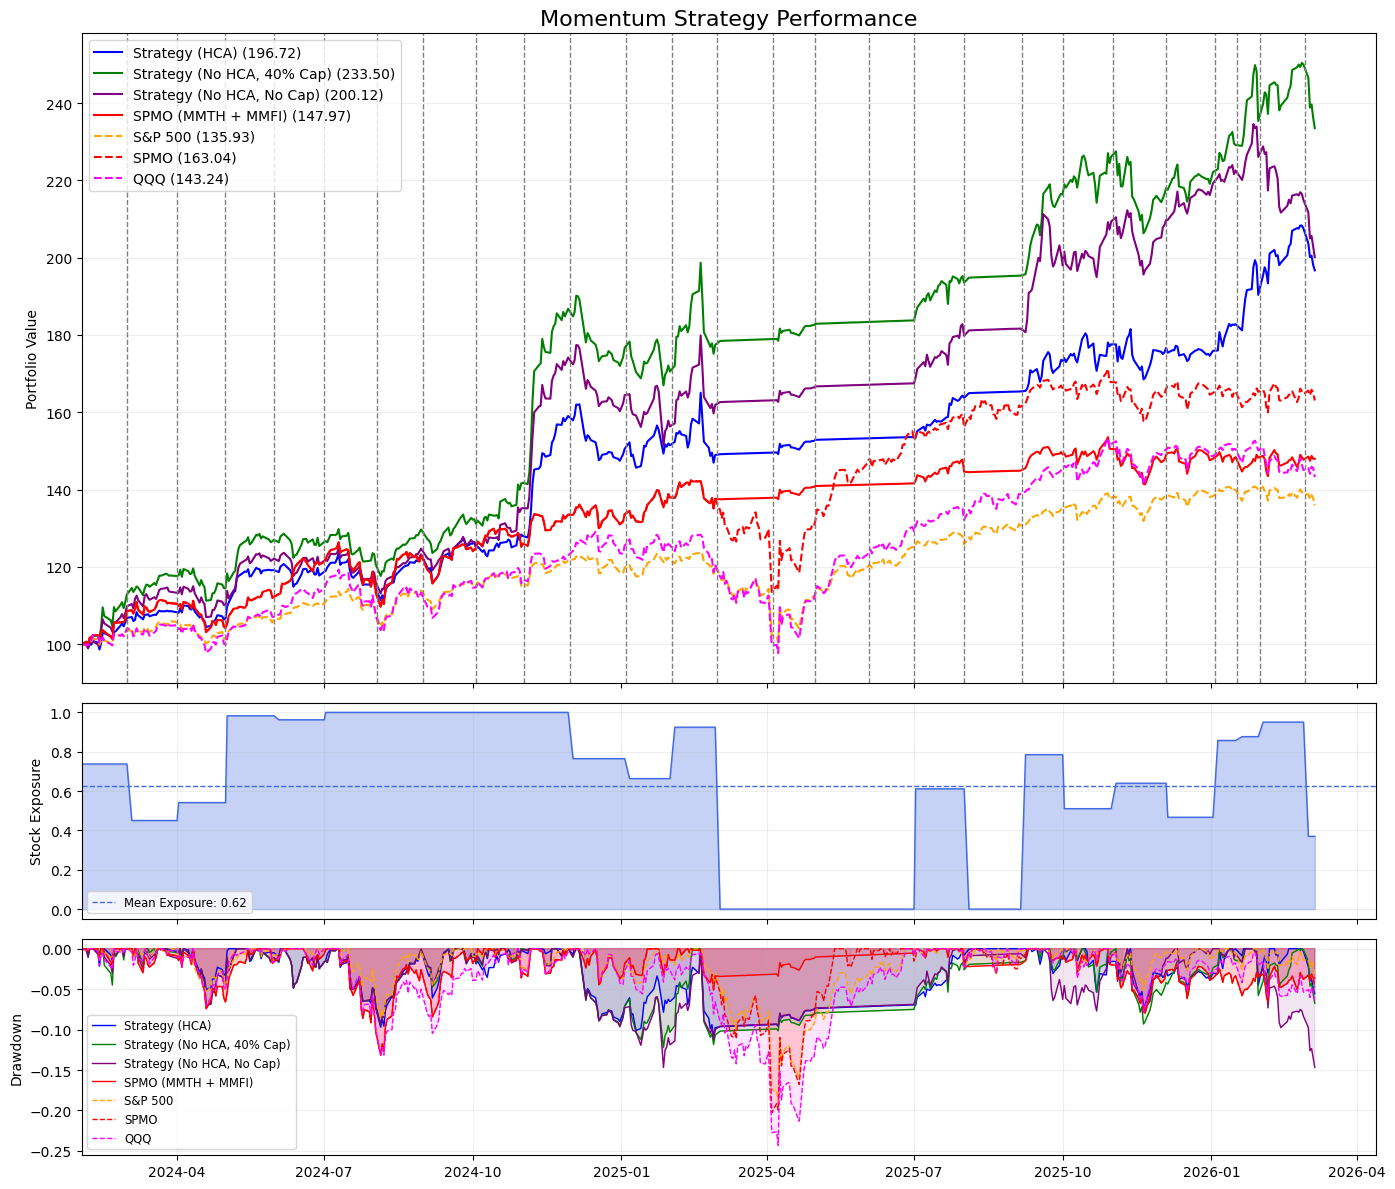

,CAGR,Sharpe,Sortino,Calmar,Annualized Vol,Max DD
Name,,,,,,
Strategy (HCA),38.25%,1.98,2.41,3.49,17.76%,-10.97%
"Strategy (No HCA, 40% Cap)",50.07%,2.26,2.68,4.10,20.87%,-12.21%
"Strategy (No HCA, No Cap)",39.39%,1.75,2.12,2.68,20.83%,-14.68%
SPMO (MMTH + MMFI),20.63%,1.15,1.62,1.57,15.36%,-13.16%
S&P 500,15.83%,0.81,1.29,0.84,15.85%,-18.90%
SPMO,26.37%,1.14,1.67,1.30,20.56%,-20.28%
QQQ,18.77%,0.74,1.23,0.77,21.20%,-24.32%


In [31]:
# --- Configuration & Initialization ---
# Retrieve the full trading calendar using the S&P 500 as a reference
sp500_df = get_df("^GSPC", current_date)
spmo_df = get_df("SPMO", current_date)
spmo_df["Daily Return"] = spmo_df["Close"] / spmo_df["Close"].shift(1)
qqq_df = get_df("^IXIC", current_date)
sp500_df["SMA 200"] = SMA(sp500_df, 200)
tqqq_df = get_df("TQQQ", current_date)
tqqq_df["Daily Return"] = tqqq_df["Close"] / tqqq_df["Close"].shift(1)
mmth_df = get_df("MMTH", current_date, method="tradingview")
mmfi_df = get_df("MMFI", current_date, method="tradingview")

# Transaction fee
transaction_fee_rate = 0.001 # 0.1% per trade
slippage_rate = 0.002 # 0.2% slippage on stop-loss execution
stop_loss = True
stop_zscore = -2.0
stop_position = 0.5

# Risk-free rate
annual_rf_rate = 0.03 # Assuming 3% annual return on cash
daily_rf_ret = (1 + annual_rf_rate) ** (1 / 252)
annual_margin_rate = 0.05 # 5% annual margin cost for leverage
daily_margin_ret = (1 + annual_margin_rate) ** (1 / 252)

# Exposure levels
prev_exposure = 0.0
prev_exposure_spmo = 0.0
mmfi_exposure = 0.05
mmfi_triggered = False
buy_tqqq = False

# --- EWMA Volatility Targeting ---
target_vol = 0.20 # Target annualized volatility (20%)
LAMBDA = 0.94 # Decay factor for EWMA

# Initialize equity and exposure curves
strats = ["hca", "nohca_cap40", "nohca_nocap", "spmo"]
labels = {"hca": "Strategy (HCA)", "nohca_cap40": "Strategy (No HCA, 40% Cap)", 
          "nohca_nocap": "Strategy (No HCA, No Cap)", "spmo": "SPMO (MMTH + MMFI)",
          "SP500": "S&P 500", "SPMO": "SPMO", "QQQ": "QQQ"}
capitals = {s: 100.0 for s in strats}
curves = {s: [] for s in strats}
equity_dates, exposure_curve = [], []

# Get backtest and trading dates
backtest_dates, trading_dates = get_backtest_trading_dates(sp500_df, rebalance_dates)

# --- Portfolio Backtest Loop ---
for i in range(len(backtest_dates) - 1):
    rebalance_date = backtest_dates[i]
    next_rebalance_date = backtest_dates[i + 1]
    signal_date = trading_dates[trading_dates <= rebalance_date][-1]
    
    try:
        buy_date = trading_dates[trading_dates > rebalance_date][0]
        valid_sell_dates = trading_dates[trading_dates > next_rebalance_date]
        sell_date = valid_sell_dates[0] if len(valid_sell_dates) > 0 else trading_dates[-1]
    except IndexError:
        print("Reached the end of available trading data.")
        break 

    # Check to ensure we have a valid trading period
    if buy_date >= sell_date:
        print(f"Skipping final period: buy_date ({buy_date.date()}) >= sell_date ({sell_date.date()})")
        break 

    # Determine the trading period
    # Use "<=" to INCLUDE the sell_date
    # We need the sell_date to calculate the "Open / Previous Close" return
    period_dates = trading_dates[(trading_dates >= buy_date) & (trading_dates <= sell_date)]

    # Calculate daily returns for all strategies
    daily_rets = {
        "hca": get_period_returns(monthly_portfolios_hca[rebalance_date], period_dates, buy_date, sell_date, sp500_df, daily_rf_ret, stop_loss=stop_loss, stop_zscore=stop_zscore, stop_position=stop_position, slippage_fee_rate=slippage_rate),
        "nohca_cap40": get_period_returns(monthly_portfolios_nohca_cap40[rebalance_date], period_dates, buy_date, sell_date, sp500_df, daily_rf_ret, stop_loss=stop_loss, stop_zscore=stop_zscore, stop_position=stop_position, slippage_fee_rate=slippage_rate),
        "nohca_nocap": get_period_returns(monthly_portfolios_nohca_nocap[rebalance_date], period_dates, buy_date, sell_date, sp500_df, daily_rf_ret, stop_loss=stop_loss, stop_zscore=stop_zscore, stop_position=stop_position, slippage_fee_rate=slippage_rate)
    }

    # EWMA volatility sizing
    portfolio_ewma = monthly_portfolios_nohca_cap40[rebalance_date]
    vol_scale = calculate_vol_scale(portfolio_ewma, rebalance_date, target_vol, LAMBDA)
    # vol_scale = calculate_vol_scale_simple(portfolio_ewma, rebalance_date, target_vol, window=21)
    active_exposure, active_exposure_spmo = calculate_exposure(mmth_df, signal_date, vol_scale)

    # --- DAILY EXECUTION LOOP ---
    # Apply initial fees
    capitals = apply_fees(capitals, abs(active_exposure - prev_exposure), transaction_fee_rate, strats=["hca", "nohca_cap40", "nohca_nocap"])
    capitals = apply_fees(capitals, abs(active_exposure_spmo - prev_exposure_spmo), transaction_fee_rate, strats=["spmo"])

    for date in period_dates:
        is_sell_date = (date == sell_date) # Identify the overlapping transition date
        for s in strats:
            exposure = active_exposure_spmo if s == "spmo" else active_exposure
            growth = get_growth(s, date, exposure, mmfi_exposure, daily_rets, daily_rf_ret, daily_margin_ret, tqqq_df, spmo_df, buy_tqqq, is_sell_date=is_sell_date)
            capitals[s] *= growth
            curves[s].append(capitals[s])
        # Update capital and equity curves
        equity_dates.append(date)
        exposure_curve.append(active_exposure) # Record current weight

        # Check for MMFI trigger TODAY to affect TOMORROW'S open
        current_mmfi = mmfi_df["Close"].loc[date]
        
        if not mmfi_triggered and current_mmfi < 10:
            mmfi_triggered = True # Trigger the MMFI condition

            # Apply fees for buying TQQQ
            capitals = apply_fees(capitals, mmfi_exposure, transaction_fee_rate)
            buy_tqqq = True

        elif mmfi_triggered and current_mmfi >= 50:
            mmfi_triggered = False # Reset the MMFI condition

            # Apply fees for selling TQQQ
            capitals = apply_fees(capitals, mmfi_exposure, transaction_fee_rate)
            buy_tqqq = False

    # Update previous exposure for next rebalance
    prev_exposure = active_exposure
    prev_exposure_spmo = active_exposure_spmo

# --- Benchmark Processing ---
results = {}
for s in strats:
    series = pd.Series(curves[s], index=equity_dates)
    # Deduplicate: Keep the "last" entry which contains the final End-of-Day compounded value
    series = series[~series.index.duplicated(keep="last")]
    results[s] = (series / series.iloc[0]) * 100

# Add Benchmarks
bench_data = {"SP500": sp500_df, "SPMO": spmo_df, "QQQ": qqq_df}
for name, df in bench_data.items():
    series = df.loc[results["hca"].index, "Close"]
    results[name] = (series / series.iloc[0]) * 100

# Calculate Metrics and Drawdowns
metrics_list = []
drawdowns = {}
for name, series in results.items():
    metrics = calculate_metrics(series)
    metrics["Name"] = labels.get(name, name)
    metrics_list.append(metrics)
    drawdowns[name] = get_drawdown(series)

metrics_df = pd.DataFrame(metrics_list).set_index("Name")

# Deduplicate the exposure series index as well
exposure_series = pd.Series(exposure_curve, index=equity_dates)
exposure_series = exposure_series[~exposure_series.index.duplicated(keep="last")]

# --- Visualization & Comparison ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]})

# Plot Equity Curves
colors = {"hca": "blue", "nohca_cap40": "green", "nohca_nocap": "purple", "spmo": "red", 
          "SP500": "orange", "SPMO": "red", "QQQ": "magenta"}
styles = {s: "-" for s in strats} | {b: "--" for b in bench_data.keys()}

# Equity curve
strat_series_hca = results["hca"]
strat_series_nohca_cap40 = results["nohca_cap40"]
strat_series_nohca_nocap = results["nohca_nocap"]
for name, series in results.items():
    ax1.plot(series, label=f"{labels.get(name, name)} ({series.iloc[-1]:.2f})", color=colors.get(name), lw=1.5, ls=styles.get(name))
ax1.set_title("Momentum Strategy Performance", fontsize=16)
ax1.set_ylabel("Portfolio Value")
ax1.legend(loc="upper left")
ax1.grid(axis="y", alpha=0.2)
ax1.set_xlim(left=strat_series_nohca_cap40.index[0])

# Stock exposure
mean_exposure = exposure_series.mean()
ax2.axhline(y=mean_exposure, color="royalblue", lw=1, ls="--", label=f"Mean Exposure: {mean_exposure:.2f}")
ax2.fill_between(exposure_series.index, exposure_series, color="royalblue", alpha=0.3)
ax2.plot(exposure_series, color="royalblue", lw=1)
ax2.set_ylabel("Stock Exposure")
ax2.legend(loc="lower left", fontsize="small")
ax2.grid(True, alpha=0.2)

# Drawdown
for name, dd in drawdowns.items():
    ax3.plot(dd, label=labels.get(name, name), color=colors.get(name), lw=1, ls=styles.get(name))
    ax3.fill_between(dd.index, dd, 0, where=(dd < 0), color=colors.get(name), alpha=0.1)
ax3.set_ylabel("Drawdown")
ax3.legend(loc="lower left", fontsize="small")
ax3.grid(True, alpha=0.2)

# Add grey vertical lines for rebalance dates
for idx, date in enumerate(pd.to_datetime(backtest_dates)):
    if strat_series_nohca_cap40.index.min() <= date < strat_series_nohca_cap40.index.max():
        ax1.axvline(x=date, color="grey", linestyle="--", linewidth=1, label="Rebalance" if idx == 0 else None)
# plt.savefig("Result/Figure/momentum_strategy_performance.png", dpi=300)
plt.tight_layout()
plt.show()

# Display Metrics DataFrame
display(metrics_df)

Applied full filters for 2026-03-05. Found 62 stocks.


Fetching price data: 100%|██████████| 62/62 [00:01<00:00, 44.44it/s]


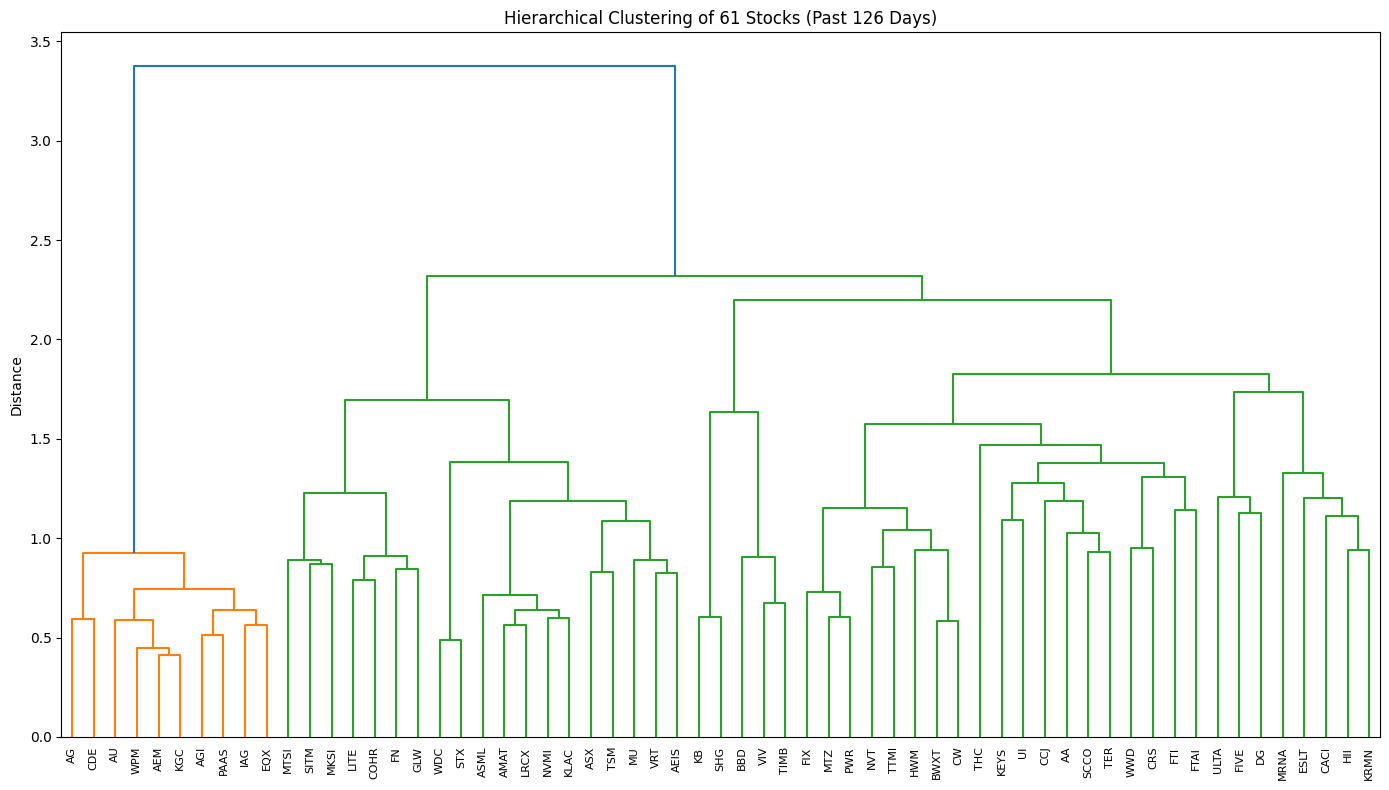

Stocks by Cluster (Ranked by Vol-adj Momentum, |Z-Score| <= 2):
Cluster 1 (10 stocks): CDE, AU, AG, IAG, KGC, AEM, PAAS, EQX, WPM, AGI
Cluster 2 (17 stocks): WDC, LITE, MU, STX, MKSI, COHR, AEIS, TSM, GLW, ASML, AMAT, MTSI, SITM, FN, NVMI, KLAC, VRT
Cluster 3 (3 stocks): BBD, VIV, TIMB
Cluster 4 (19 stocks): FIX, TTMI, FTI, CCJ, CW, TER, NVT, SCCO, WWD, FTAI, MTZ, PWR, BWXT, HWM, AA, CRS, UI, THC, KEYS
Cluster 5 (7 stocks): FIVE, HII, DG, KRMN, ULTA, CACI, MRNA
Number of stocks after Z-Score filtering: 56


Portfolio for 2026-03-05:



,Cluster,Stock,Market Cap,Volatility,Vol-adj Momentum,Vol-adj Idio Momentum,Z-Score,Weight (%)
0,3,BBD,41.36,0.024515,44.725227,39.197244,-1.422273,24.160966
1,1,CDE,15.26,0.050857,61.194798,55.826162,-0.659087,11.646577
2,5,FIVE,12.16,0.017151,80.393765,59.233627,-0.444352,34.534885
3,4,FIX,50.45,0.032342,79.384518,68.698418,-0.600144,18.314039
4,2,WDC,89.34,0.052216,105.394556,98.247126,-1.810922,11.343533


In [32]:
# --- Parameters ---
days_per_week = 5  # Trading days in a week
num_weeks = 52  # Weeks in a year
period_week_zscore = days_per_week * num_weeks  # 1-year lookback for weekly return z-score
period_pca = 126  # 6-month lookback for PCA clustering
period_mom_short = 21  # 1-month lookback for short-term momentum
period_mom_long = 252  # 1-year lookback for long-term momentum
period_vol = 60  # 3-month volatility window
num_clusters = 5  # Number of clusters for hierarchical grouping
num_stocks = 5  # Number of stocks to select for the portfolio
parameters = {
    "days_per_week": days_per_week,
    "period_week_zscore": period_week_zscore,
    "period_pca": period_pca,
    "period_mom_short": period_mom_short,
    "period_mom_long": period_mom_long,
    "period_vol": period_vol,
    "num_clusters": num_clusters,
    "num_stocks": num_stocks
}

# Current portfolio
rebalance_date = "2026-03-05"
current_portfolio_df, num_stocks_filtered, current_df_combined = construct_month_portfolio(rebalance_date, index_name, index_dict, 
                                                                                           parameters, use_hca=True, hca_linkage="ward", 
                                                                                           display_dendrogram=True, cluster_cap=0.4, exclude_stocks="EXAS")
print(f"\nPortfolio for {rebalance_date}:\n")
display(current_portfolio_df)

In [33]:
# --- Calculate Number of Shares to Buy in FUTU ---
total_capital = 580000
stock_weight = 0.3
current_stocks = []

# EWMA volatility sizing
vol_scale = calculate_vol_scale(current_portfolio_df, rebalance_date, target_vol, LAMBDA)
print(f"EWMA Volatility Scale Factor: {vol_scale:.4f}\n")

# Calculate the capital allocated to stocks
stock_capital = total_capital * stock_weight * vol_scale
    
for _, row in current_portfolio_df.iterrows():
    stock = row["Stock"]
    current_stocks.append(stock)
    weight = row["Weight (%)"]
    df = get_df(stock, rebalance_date)
    df = df[df.index <= rebalance_date]
    recent_close = df["Close"].iloc[-1]
    num_shares = int(np.floor(stock_capital * weight / 100 / 7.8 / recent_close))
    print(f"Stock: {stock}, Weight: {weight:.2f}%, Recent Close: {recent_close:.2f}, Shares to Buy: {num_shares}")
    print("Amount in HKD: {:.2f}\n".format(num_shares * recent_close * 7.8))

EWMA Volatility Scale Factor: 0.5779

Stock: BBD, Weight: 24.16%, Recent Close: 3.74, Shares to Buy: 832
Amount in HKD: 24271.10

Stock: CDE, Weight: 11.65%, Recent Close: 22.63, Shares to Buy: 66
Amount in HKD: 11649.92

Stock: FIVE, Weight: 34.53%, Recent Close: 221.65, Shares to Buy: 20
Amount in HKD: 34577.40

Stock: FIX, Weight: 18.31%, Recent Close: 1348.22, Shares to Buy: 1
Amount in HKD: 10516.12

Stock: WDC, Weight: 11.34%, Recent Close: 259.03, Shares to Buy: 5
Amount in HKD: 10102.17



In [34]:
# --- Calculate Sell Price Levels Based on Weekly Return Z-Score ---
spread = 0.01
current_stocks = ["WDC"]

for stock in current_stocks:
    # Extract the closing price data
    df = get_df(stock, current_date)
    df = df[df.index <= "2026-03-07"] # Use the last day of February for the z-score calculation
    df_prices = df["Close"].tail(period_week_zscore + 1)
    recent_close = df_prices.iloc[-1]

    # Reverse the rows so we start sampling from the most recent day
    df_prices_rev = df_prices.iloc[::-1]
    
    # Sample every "days_per_week" starting from the last day
    weekly_prices_rev = df_prices_rev.iloc[::days_per_week]
    
    # Reverse back to chronological order
    weekly_prices = weekly_prices_rev.iloc[::-1]
    
    # Compute weekly returns
    weekly_returns = weekly_prices.pct_change(fill_method=None).dropna()
    
    # Compute statistics
    mean_return = weekly_returns.mean()
    std_return = weekly_returns.std()
    
    # Calculate -2 sigma and +3 sigma price
    down_2sigma = recent_close * (1 + mean_return - 2 * std_return)
    down_sell = down_2sigma * (1 + spread)
    up_3sigma = recent_close * (1 + mean_return + 3 * std_return)
    up_sell = up_3sigma * (1 - spread)

    print(f"Stock: {stock}, Recent Close: {recent_close:.2f}, Mean Return: {mean_return:.4f}, Std Return: {std_return:.4f}")
    print(f"-2σ Price: {down_2sigma:.2f}, Down Sell: {down_sell:.2f}, +3σ Price: {up_3sigma:.2f}, Up Sell: {up_sell:.2f}\n")

Stock: WDC, Recent Close: 245.25, Mean Return: 0.0344, Std Return: 0.0901
-2σ Price: 209.46, Down Sell: 211.55, +3σ Price: 320.00, Up Sell: 316.80



In [37]:
# ETF weights
etf_weights_original = {
    "SPMO": 0.075,
    "IDMO": 0.075,
    "MGV": 0.100,
    "EFV": 0.025,
    "XMMO": 0.05,
    "3070.HK": 0.025,
    "EWO": 0.025,
    "EWY": 0.025
}

# Normalize weights by dividing by 0.4
etf_weights = {ticker: weight / 0.4 for ticker, weight in etf_weights_original.items()}

# Fetch ETF data
etf_data = {}
for ticker in etf_weights.keys():
    df = get_df(ticker, current_date)
    if df is not None and not df.empty:
        etf_data[ticker] = df["Close"]
    else:
        print(f"Warning: No data found for {ticker}")

# Find the earliest date where all ETFs exist
if etf_data:
    earliest_date = max(series.index.min() for series in etf_data.values())
    print(f"Earliest common date: {earliest_date}")
    
    # Align all series to start from the earliest common date
    aligned_data = pd.DataFrame({ticker: series[series.index >= earliest_date] for ticker, series in etf_data.items()})
    
    # Calculate daily returns for each ETF
    etf_returns = aligned_data.pct_change(fill_method=None).fillna(0)
    
    # Calculate weighted portfolio returns
    portfolio_returns = sum(etf_returns[ticker] * weight for ticker, weight in etf_weights.items())
    
    # Calculate cumulative equity curve
    etf_portfolio_equity = (1 + portfolio_returns).cumprod() * 100
    
    print(f"\nETF Portfolio Weights (normalized):")
    for ticker, weight in etf_weights.items():
        print(f"{ticker}: {weight:.2%}")
    
    print(f"\nPortfolio Value: {etf_portfolio_equity.iloc[-1]:.2f}")
else:
    print("No ETF data available")
    etf_portfolio_equity = pd.Series(dtype=float)

# Metrics
etf_metrics = calculate_metrics(etf_portfolio_equity)
print("\nETF Portfolio Performance Metrics:")
for metric, value in etf_metrics.items():
    print(f"{metric}: {value}")

Earliest common date: 2015-10-12 00:00:00

ETF Portfolio Weights (normalized):
SPMO: 18.75%
IDMO: 18.75%
MGV: 25.00%
EFV: 6.25%
XMMO: 12.50%
3070.HK: 6.25%
EWO: 6.25%
EWY: 6.25%

Portfolio Value: 344.72

ETF Portfolio Performance Metrics:
CAGR: 12.64%
Sharpe: 0.63
Sortino: 0.97
Calmar: 0.38
Annualized Vol: 15.27%
Max DD: -33.35%


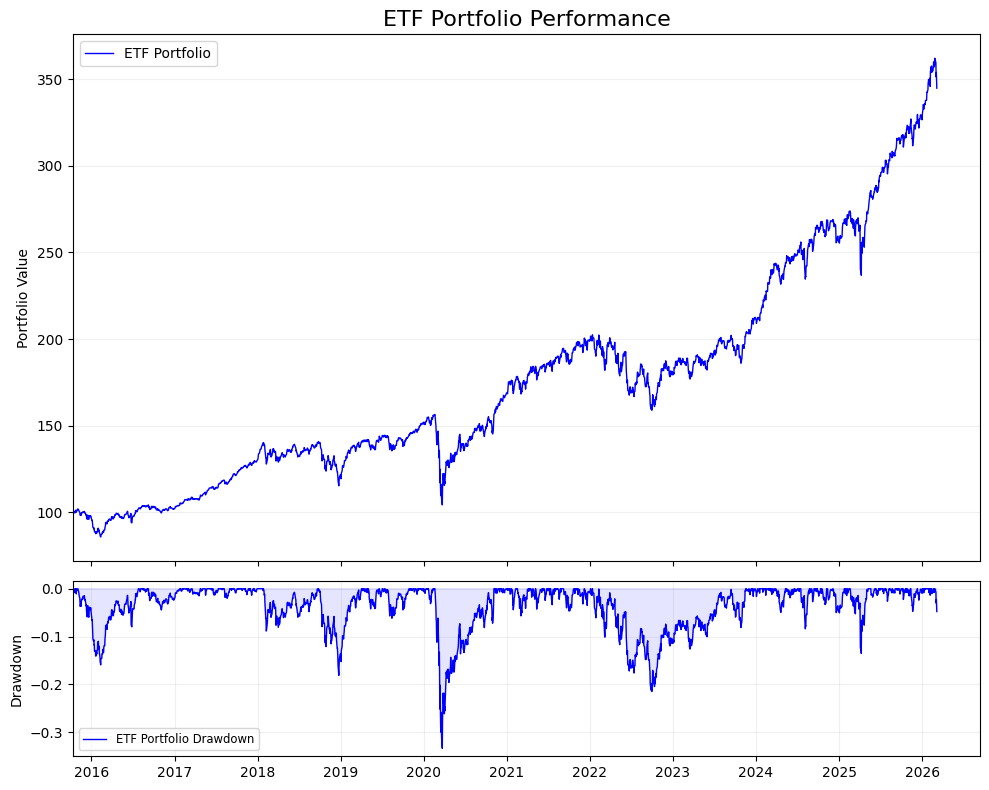

In [38]:
# --- Visualization & Comparison ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

# Equity curve
ax1.plot(etf_portfolio_equity, label="ETF Portfolio", color="blue", lw=1)
ax1.set_title("ETF Portfolio Performance", fontsize=16)
ax1.set_ylabel("Portfolio Value")
ax1.legend(loc="upper left")
ax1.grid(axis="y", alpha=0.2)
ax1.set_xlim(left=etf_portfolio_equity.index[0])

# Drawdown
etf_dd = get_drawdown(etf_portfolio_equity)
ax2.plot(etf_dd, label="ETF Portfolio Drawdown", color="blue", lw=1)
ax2.fill_between(etf_dd.index, etf_dd, 0, where=(etf_dd < 0), color="blue", alpha=0.1)
ax2.set_ylabel("Drawdown")
ax2.legend(loc="lower left", fontsize="small")
ax2.grid(True, alpha=0.2)

# Adjust the layout
plt.tight_layout()
plt.show()

In [39]:
# Read and process the Fama-French 5 Factors data
ff5_data = pd.read_csv("Program/F-F_Research_Data_5_Factors_2x3_daily.csv", skiprows=3, index_col=0)
ff5_data = ff5_data.drop(ff5_data.index[-1])

# Convert index to datetime for time series analysis
ff5_data.index = pd.to_datetime(ff5_data.index, format="%Y%m%d")

# Read and process the momentum factor data
ffwml_data = pd.read_csv("Program/F-F_Momentum_Factor_daily.csv", skiprows=13, index_col=0)
ffwml_data = ffwml_data.drop(ffwml_data.index[-1])

# Convert index to datetime for time series analysis
ffwml_data.index = pd.to_datetime(ffwml_data.index, format="%Y%m%d")

# Rename the column from Mom to WML
ffwml_data = ffwml_data.rename(columns={"Mom": "WML"})

In [40]:
def ff6_decompose(df, ff5_data, ffwml_data):
    """
    Decomposes the stock factor into Fama-French 5 factors and WML with optimized performance.

    Parameters:
    df (DataFrame): DataFrame containing stock prices with "Close" column.
    ff5_data (DataFrame): Fama-French 5 factors data.
    ffwml_data (DataFrame): Momentum factor data.
    
    Returns:
    dict: Dictionary containing regression results and additional metrics.
    """
    
    # Calculate daily returns for stock
    stock_returns = df["Close"].pct_change().dropna() * 100
    
    # Get date range
    start_date, end_date = stock_returns.index[0], stock_returns.index[-1]

    # Filter factor data using boolean indexing
    date_mask_ff5 = (ff5_data.index >= start_date) & (ff5_data.index <= end_date)
    date_mask_wml = (ffwml_data.index >= start_date) & (ffwml_data.index <= end_date)
    
    ff5_stock = ff5_data.loc[date_mask_ff5]
    ffwml_stock = ffwml_data.loc[date_mask_wml]
    
    # Combine factors
    factors_stock = ff5_stock[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].join(
        ffwml_stock["WML"], how="inner"
    )

    # Align data using intersection
    common_dates = stock_returns.index.intersection(factors_stock.index)
    stock_aligned = stock_returns.loc[common_dates]
    factors_aligned = factors_stock.loc[common_dates]
    rf_aligned = ff5_stock.loc[common_dates, "RF"]
    
    # Calculate excess returns
    stock_excess = stock_aligned - rf_aligned

    # Remove NaN values
    combined_data = pd.concat([factors_aligned, stock_excess], axis=1)
    clean_data = combined_data.dropna()
    
    X_clean = clean_data.iloc[:, :-1] # All factors
    y_clean = clean_data.iloc[:, -1] # Excess returns
    
    # Fit regression model using statsmodels for p-values and t-stats
    X_with_const = sm.add_constant(X_clean)
    ols_model = sm.OLS(y_clean, X_with_const).fit()
    
    # Extract results
    alpha = ols_model.params["const"]
    factor_names = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "WML"]
    betas = ols_model.params[factor_names].values
    r_squared = ols_model.rsquared
    
    # Extract t-stats and p-values
    t_stats = ols_model.tvalues
    p_values = ols_model.pvalues

    # Calculate factor contributions
    contributions = pd.DataFrame(
        X_clean.values * betas, 
        index=X_clean.index,
        columns=X_clean.columns
    )
    contributions["Alpha"] = alpha

    # Print results
    print(f"Alpha (intercept): {alpha:.4f}%  (t={t_stats['const']:.2f}, p={p_values['const']:.4f})")
    print(f"R-squared: {r_squared:.4f}")
    print(f"\n{'Factor':<8} {'Beta':>10} {'t-stat':>10} {'p-value':>10} {'Sig':>5}")
    print("-" * 48)

    for name in factor_names:
        beta = ols_model.params[name]
        t = t_stats[name]
        p = p_values[name]
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
        print(f"{name:<8} {beta:>10.4f} {t:>10.2f} {p:>10.4f} {sig:>5}")
    
    print(f"\nPeriod: {common_dates[0].strftime('%Y-%m-%d')} to {common_dates[-1].strftime('%Y-%m-%d')}")
    print(f"Number of observations: {len(X_clean)}")
    
    # Return results dictionary
    return {
        "alpha": alpha,
        "betas": betas,
        "r_squared": r_squared,
        "t_stats": t_stats,
        "p_values": p_values,
        "contributions": contributions,
        "n_observations": len(X_clean),
        "period": (common_dates[0], common_dates[-1]),
        "ols_summary": ols_model
    }

In [41]:
# Perform Fama-French 6-factor decomposition
strat_series_hca_df = strat_series_hca.to_frame(name="Close")
strat_series_nohca_cap40_df = strat_series_nohca_cap40.to_frame(name="Close")
strat_series_nohca_nocap_df = strat_series_nohca_nocap.to_frame(name="Close")
ff6_result_hca = ff6_decompose(strat_series_hca_df, ff5_data, ffwml_data)

Alpha (intercept): 0.0793%  (t=1.96, p=0.0508)
R-squared: 0.3467

Factor         Beta     t-stat    p-value   Sig
------------------------------------------------
Mkt-RF       0.3709       8.29     0.0000   ***
SMB          0.1800       2.46     0.0144    **
HML         -0.1480      -2.14     0.0325    **
RMW         -0.1111      -1.24     0.2148      
CMA          0.1168       1.28     0.1998      
WML          0.4267       7.81     0.0000   ***

Period: 2024-02-05 to 2026-01-30
Number of observations: 499


In [42]:
ff6_result_spmo = ff6_decompose(spmo_df, ff5_data, ffwml_data)

Alpha (intercept): 0.0049%  (t=0.45, p=0.6543)
R-squared: 0.8055

Factor         Beta     t-stat    p-value   Sig
------------------------------------------------
Mkt-RF       0.9752      98.22     0.0000   ***
SMB         -0.1490      -8.06     0.0000   ***
HML         -0.0399      -2.39     0.0170    **
RMW         -0.0077      -0.33     0.7399      
CMA          0.1106       3.98     0.0001   ***
WML          0.2359      21.65     0.0000   ***

Period: 2015-10-13 to 2026-01-30
Number of observations: 2590


In [45]:
etf_portfolio_df = etf_portfolio_equity.to_frame(name="Close")
ff6_result_etf = ff6_decompose(etf_portfolio_df, ff5_data, ffwml_data)

Alpha (intercept): 0.0025%  (t=0.37, p=0.7127)
R-squared: 0.8752

Factor         Beta     t-stat    p-value   Sig
------------------------------------------------
Mkt-RF       0.7942     127.66     0.0000   ***
SMB         -0.0138      -1.19     0.2336      
HML          0.1396      13.33     0.0000   ***
RMW         -0.0434      -3.00     0.0027   ***
CMA          0.0461       2.65     0.0082   ***
WML          0.0644       9.43     0.0000   ***

Period: 2015-10-13 to 2026-01-30
Number of observations: 2590


In [44]:
brkb_df = get_df("BRK-B", current_date)
ff6_result_brkb = ff6_decompose(brkb_df, ff5_data, ffwml_data)

Alpha (intercept): 0.0153%  (t=1.20, p=0.2312)
R-squared: 0.3786

Factor         Beta     t-stat    p-value   Sig
------------------------------------------------
Mkt-RF       0.6497      55.33     0.0000   ***
SMB         -0.1362      -6.39     0.0000   ***
HML          0.4740      21.64     0.0000   ***
RMW         -0.1448      -5.22     0.0000   ***
CMA          0.0227       0.65     0.5184      
WML          0.0061       0.44     0.6603      

Period: 1996-05-10 to 2026-01-30
Number of observations: 7479
